# TATA COFFEE 
## STOCK PRICE PREDICTION

### Using Monthly Close Price

**Company:** Tata Coffee  
**Period:** 01-06-2021 to 05-01-2022  
**Target Variable:** Monthly Close Price  
**Machine Learning Technique:** Regression  
**Algorithm:** Linear Regression

In [1]:
!pip install nsepy 

In [2]:
!pip install yfinance

In [3]:
import yfinance as yf
print("yfinance imported successfully")

yfinance imported successfully


In [4]:
import pandas as pd

data = {
    "Date": [
        "2021-06-01",
        "2021-07-01",
        "2021-08-02",
        "2021-09-01",
        "2021-10-01",
        "2021-11-01",
        "2021-12-01",
        "2022-01-03",
        "2022-01-05"
    ],
    
    "Close": [
        168.00,
        182.15,
        178.60,
        197.30,
        200.70,
        192.15,
        190.30,
        200.00,
        202.00
    ]
}
stk_data = pd.DataFrame(data)

stk_data["Date"] = pd.to_datetime(stk_data["Date"])

print(stk_data)


        Date   Close
0 2021-06-01  168.00
1 2021-07-01  182.15
2 2021-08-02  178.60
3 2021-09-01  197.30
4 2021-10-01  200.70
5 2021-11-01  192.15
6 2021-12-01  190.30
7 2022-01-03  200.00
8 2022-01-05  202.00


In [5]:
stk_data.head()

,Date,Close
0,2021-06-01,168.00
1,2021-07-01,182.15
2,2021-08-02,178.60
3,2021-09-01,197.30
4,2021-10-01,200.70


In [6]:
print("Shape of data:", stk_data.shape)
print("\nColumn names:")
print(stk_data.columns)

print("\nData information:")
print(stk_data.info())

print("\nStatistical summary:")
print(stk_data.describe())

Shape of data: (9, 2)

Column names:
Index(['Date', 'Close'], dtype='object')

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9 non-null      datetime64[ns]
 1   Close   9 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 272.0 bytes
None

Statistical summary:
                      Date       Close
count                    9    9.000000
mean   2021-09-28 13:20:00  190.133333
min    2021-06-01 00:00:00  168.000000
25%    2021-08-02 00:00:00  182.150000
50%    2021-10-01 00:00:00  192.150000
75%    2021-12-01 00:00:00  200.000000
max    2022-01-05 00:00:00  202.000000
std                    NaN   11.682867


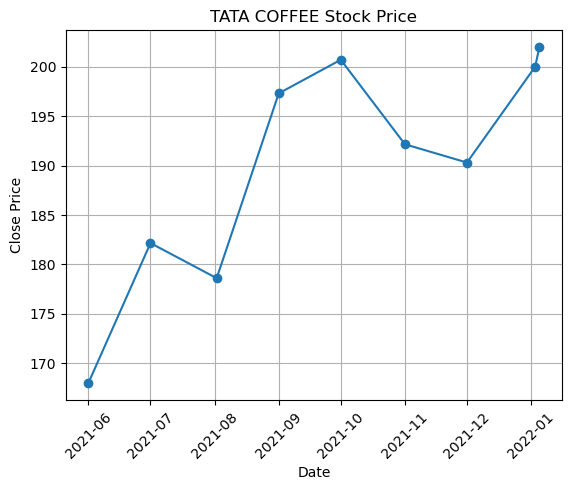

In [7]:
import matplotlib.pyplot as plt

plt.plot(stk_data["Date"], stk_data["Close"], marker="o")

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("TATA COFFEE Stock Price")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [8]:
print("Maximum Close Price:", stk_data["Close"].max())
print("Minimum Close Price:", stk_data["Close"].min())
print("Average Close Price:", stk_data["Close"].mean())

Maximum Close Price: 202.0
Minimum Close Price: 168.0
Average Close Price: 190.13333333333333


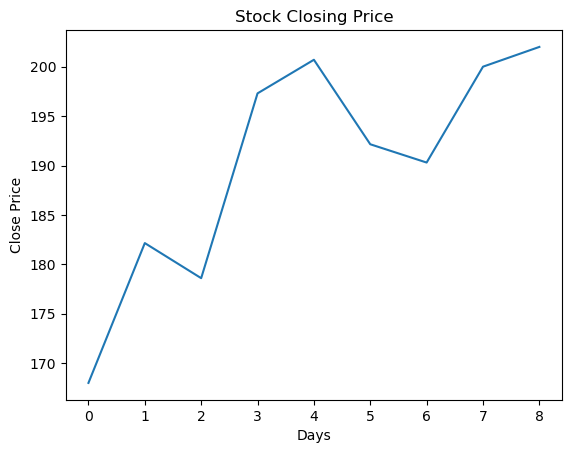

In [10]:
import matplotlib.pyplot as plt

plt.plot(stk_data["Close"])
plt.title("Stock Closing Price")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.show()

In [9]:
print(stk_data.head())

        Date   Close
0 2021-06-01  168.00
1 2021-07-01  182.15
2 2021-08-02  178.60
3 2021-09-01  197.30
4 2021-10-01  200.70


In [10]:
stk_data["Date"] = pd.to_datetime(stk_data["Date"])
stk_data = stk_data.sort_values("Date")
print(stk_data.head())

        Date   Close
0 2021-06-01  168.00
1 2021-07-01  182.15
2 2021-08-02  178.60
3 2021-09-01  197.30
4 2021-10-01  200.70


In [11]:
stk_data = stk_data[["Date", "Close"]]

print(stk_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9 non-null      datetime64[ns]
 1   Close   9 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 272.0 bytes
None


In [12]:
stk_data = stk_data.set_index("Date")

print(stk_data)

             Close
Date              
2021-06-01  168.00
2021-07-01  182.15
2021-08-02  178.60
2021-09-01  197.30
2021-10-01  200.70
2021-11-01  192.15
2021-12-01  190.30
2022-01-03  200.00
2022-01-05  202.00


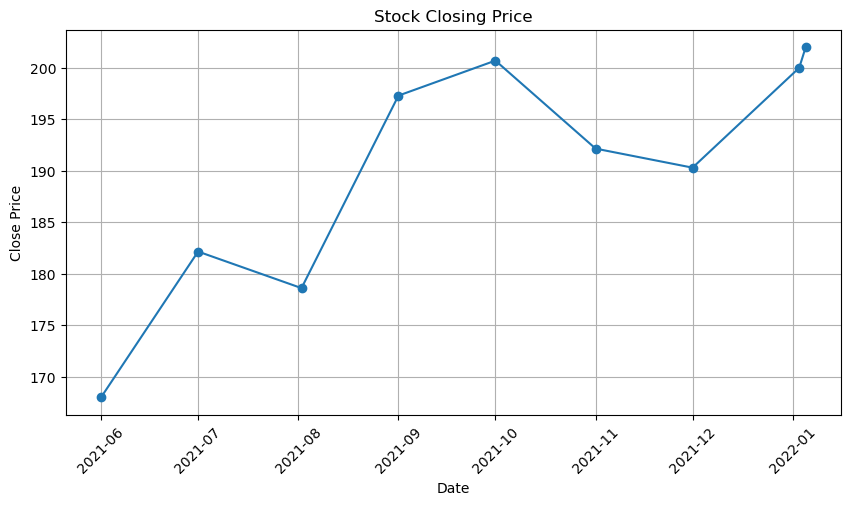

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(stk_data.index, stk_data["Close"], marker="o")
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [14]:
X = stk_data.index
y = stk_data["Close"]

print("X:")
print(X)

print("\ny:")
print(y)

X:
DatetimeIndex(['2021-06-01', '2021-07-01', '2021-08-02', '2021-09-01',
               '2021-10-01', '2021-11-01', '2021-12-01', '2022-01-03',
               '2022-01-05'],
              dtype='datetime64[ns]', name='Date', freq=None)

y:
Date
2021-06-01    168.00
2021-07-01    182.15
2021-08-02    178.60
2021-09-01    197.30
2021-10-01    200.70
2021-11-01    192.15
2021-12-01    190.30
2022-01-03    200.00
2022-01-05    202.00
Name: Close, dtype: float64


In [28]:
import numpy as np

X = np.arange(len(stk_data)).reshape(-1, 1)
y = stk_data["Close"].values

print("X:")
print(X)

print("\ny:")
print(y)

X:
[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]]

y:
[168.   182.15 178.6  197.3  200.7  192.15 190.3  200.   202.  ]


In [15]:
import numpy as np
print(np.__version__)

1.26.4


In [16]:
X = np.arange(len(stk_data)).reshape(-1, 1)
y = stk_data["Close"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9, 1)
y shape: (9,)


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Model trained successfully")

C:\Users\GOD\Anaconda3\envs\ai310\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Model trained successfully


In [18]:
next_day = np.array([[9]])

predicted_price = model.predict(next_day)

print("Predicted Close Price:", predicted_price[0])

Predicted Close Price: 207.45


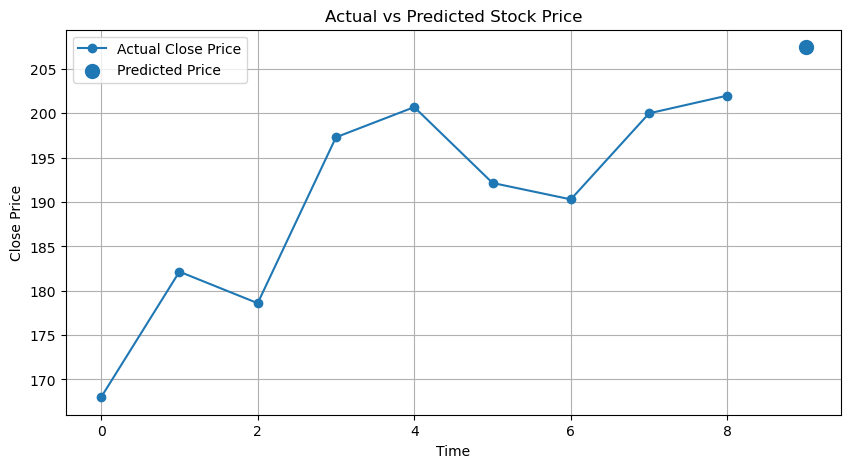

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(range(len(y)), y, marker="o", label="Actual Close Price")
plt.scatter(9, predicted_price[0], s=100, label="Predicted Price")

plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)

print("R² Score:", r2)

R² Score: 0.6590995330833145


In [21]:
y_pred = model.predict(X)

for actual, predicted in zip(y, y_pred):
    print("Actual:", actual, "Predicted:", round(predicted, 2))

Actual: 168.0 Predicted: 176.28
Actual: 182.15 Predicted: 179.74
Actual: 178.6 Predicted: 183.21
Actual: 197.3 Predicted: 186.67
Actual: 200.7 Predicted: 190.13
Actual: 192.15 Predicted: 193.6
Actual: 190.3 Predicted: 197.06
Actual: 200.0 Predicted: 200.52
Actual: 202.0 Predicted: 203.99


In [22]:
future_X = np.array([[9]])

future_price = model.predict(future_X)[0]

print("Next Predicted Close Price: ₹", round(future_price, 2))

Next Predicted Close Price: ₹ 207.45


In [23]:
future_X = np.array([[9]])

future_price = model.predict(future_X)[0]

print("Next Predicted Close Price: ₹", round(future_price, 2))

Next Predicted Close Price: ₹ 207.45


In [ ]:
Next Predicted Close Price = ₹207.45
R² Score = 0.6591

In [29]:
print(stk_data.tail())

             Close
Date              
2021-10-01  200.70
2021-11-01  192.15
2021-12-01  190.30
2022-01-03  200.00
2022-01-05  202.00
